In [13]:
import os
import pandas as pd
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ===============================
# 1. DOWNLOAD DATASET FROM KAGGLE
# ===============================
print("Downloading dataset from Kaggle...")

os.system("kaggle datasets download -d uciml/sms-spam-collection-dataset")
os.system("unzip -o sms-spam-collection-dataset.zip")

print("Dataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
sms-spam-collection-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                
Dataset downloaded and extracted!


In [3]:
# ===============================
# 2. LOAD DATASET
# ===============================
df = pd.read_csv("spam.csv", encoding="latin-1")

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

/tmp/ipykernel_14667/3322977013.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


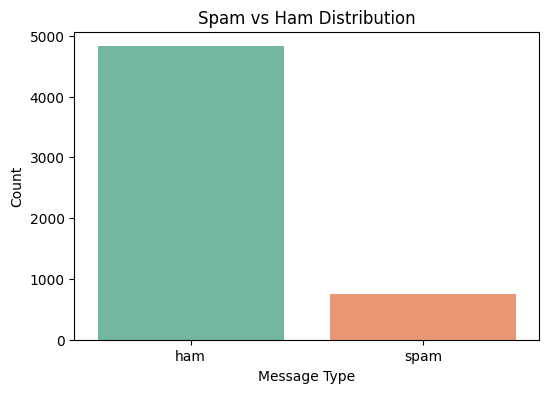

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

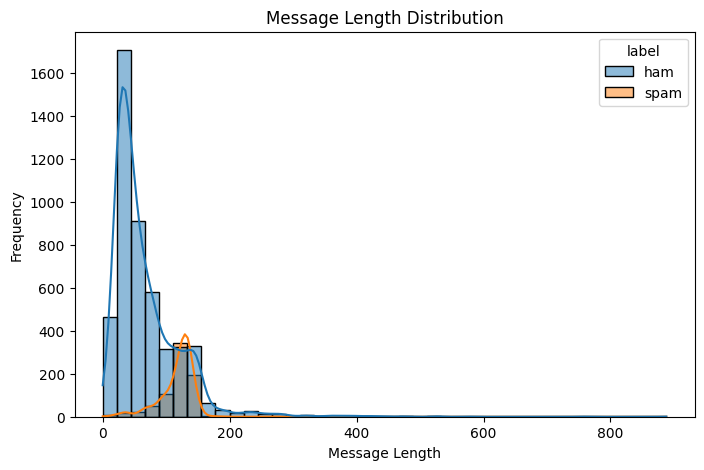

In [15]:
df['length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='length', hue='label', bins=40, kde=True)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

In [4]:
# ===============================
# 3. CLEAN TEXT
# ===============================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip()
    return text

df['message'] = df['message'].apply(clean_text)

In [5]:
# ===============================
# 4. SPLIT DATA
# ===============================
X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# ===============================
# 5. TEXT VECTORIZATION
# ===============================
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [7]:
# ===============================
# 6. MODEL TRAINING
# ===============================
model = MultinomialNB()
model.fit(X_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


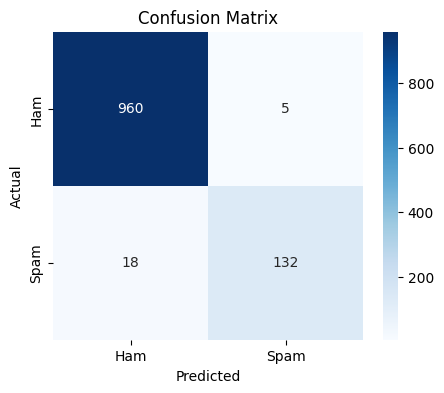

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','Spam'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
# ===============================
# 7. PREDICTION
# ===============================
y_pred = model.predict(X_test_vec)

In [9]:
# ===============================
# 8. EVALUATION
# ===============================
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.979372197309417

Classification Report:

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       965
        spam       0.96      0.88      0.92       150

    accuracy                           0.98      1115
   macro avg       0.97      0.94      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [10]:
# ===============================
# 9. REAL-TIME PREDICTION
# ===============================
def predict_message(msg):
    msg = clean_text(msg)
    vec = vectorizer.transform([msg])
    return model.predict(vec)[0]

print("\n--- TEST EXAMPLES ---")
print(predict_message("Congratulations! You won a free iPhone"))
print(predict_message("Hey, are we meeting today?"))


--- TEST EXAMPLES ---
spam
ham


In [11]:
# ===============================
# 10. INTERACTIVE MODE
# ===============================
print("\nType messages (type 'exit' to stop)")
while True:
    msg = input("Enter message: ")
    if msg.lower() == "exit":
        break
    print("Prediction:", predict_message(msg))


Type messages (type 'exit' to stop)
Prediction: spam
Prediction: spam
Prediction: ham


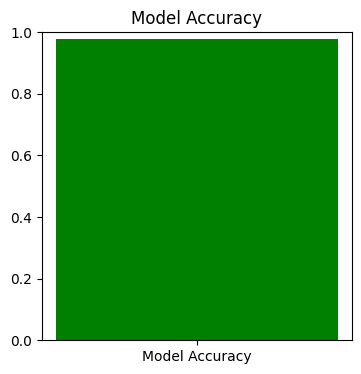

Bad pipe message: %s [b'0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7\r\nHost: localhost:45819\r\nUs', b'-Agent: Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/134.0.0.0 Safa']
Bad pipe message: %s [b'/537.36\r\nAccept-Encoding: gzip, deflate, br, zstd\r\nAccept-Language: en-GB,en-US;q=0.9,en;q=0.8\r\nCache-Control: ma', b'age=0\r\nReferer: https://github.com/\r\nX-Request-ID: 6e8be98b2a2ea8639014cc5d6b996b25\r\nX-Real-IP: 27.107.28.74\r\nX-Forward', b'-Port: 443\r\nX-Forwarded-Scheme: https\r\nX-Original-URI: /\r\nX-Scheme: https\r\nsec-fetch-site: cross-sit']
Bad pipe message: %s [b'\nsec-fetch-mode: navigate\r\nsec-fetch-dest: document\r\nsec-ch-ua: "Chromium";v="134", "Not:A-Brand";v=', b'4", "Google Chrome";v="134"\r\nsec-']
Bad pipe message: %s [b'-ua-mobile: ?0\r\nsec-ch-ua-platform: "Linux"\r\npriority: u=0, i\r\nX-Forwarded-Proto: https\r\nX-Forward']
Bad pipe message: %s [b'-Host: stunning-space-guacamole-

In [17]:
accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.bar(["Model Accuracy"], [accuracy], color='green')
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.show()

In [19]:
!pip install streamlit

  Obtaining dependency information for streamlit from https://files.pythonhosted.org/packages/e4/91/cb6f13a89e376ef179309d74f37a70ea0041d5e4b5ba5c4836dbf6e020ad/streamlit-1.56.0-py3-none-any.whl.metadata
  Obtaining dependency information for altair!=5.4.0,!=5.4.1,<7,>=4.0 from https://files.pythonhosted.org/packages/db/33/ef2f2409450ef6daa61459d5de5c08128e7d3edb773fefd0a324d1310238/altair-6.0.0-py3-none-any.whl.metadata
  Obtaining dependency information for blinker<2,>=1.5.0 from https://files.pythonhosted.org/packages/10/cb/f2ad4230dc2eb1a74edf38f1a38b9b52277f75bef262d8908e60d957e13c/blinker-1.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for cachetools<8,>=5.5 from https://files.pythonhosted.org/packages/06/f3/39cf3367b8107baa44f861dc802cbf16263c945b62d8265d36034fc07bea/cachetools-7.0.5-py3-none-any.whl.metadata
  Obtaining dependency information for gitpython!=3.1.19,<4,>=3.0.7 from https://files.pythonhosted.org/packages/6a/09/e21df6aef1e1ffc0c816f0522ddc3f6dcd

In [21]:
# ==========================================
# 📧 SPAM SMS DETECTION - STREAMLIT APP
# ==========================================

import streamlit as st
import pandas as pd
import re
import string

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# ------------------------------------------
# 1. PAGE CONFIGURATION
# ------------------------------------------
st.set_page_config(
    page_title="Spam SMS Detector",
    page_icon="📧",
    layout="centered"
)

st.title("📧 Spam SMS Detection App")
st.write("Enter a message and check whether it is Spam or Not Spam (Ham).")

# ------------------------------------------
# 2. LOAD DATASET (you can also use Kaggle file)
# ------------------------------------------
df = pd.read_csv("spam.csv", encoding="latin-1")
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# ------------------------------------------
# 3. TEXT CLEANING FUNCTION
# ------------------------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

df['message'] = df['message'].apply(clean_text)

# ------------------------------------------
# 4. TRAIN MODEL (simple in app for demo)
# ------------------------------------------
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['label']

model = MultinomialNB()
model.fit(X, y)

# ------------------------------------------
# 5. USER INPUT UI
# ------------------------------------------
user_input = st.text_area("✍ Enter your message:")

# ------------------------------------------
# 6. PREDICTION BUTTON
# ------------------------------------------
if st.button("Predict"):
    if user_input.strip() == "":
        st.warning("Please enter a message first!")
    else:
        cleaned = clean_text(user_input)
        vector = vectorizer.transform([cleaned])
        prediction = model.predict(vector)[0]

        # --------------------------------------
        # OUTPUT RESULT
        # --------------------------------------
        if prediction == "spam":
            st.error("🚫 This is SPAM message!")
        else:
            st.success("✅ This is NOT Spam (Ham)")

# ------------------------------------------
# 7. SIDEBAR INFO
# ------------------------------------------
st.sidebar.title("ℹ About")
st.sidebar.write("""
This app uses Machine Learning (Naive Bayes)
and NLP techniques to detect spam messages.

Dataset: Kaggle SMS Spam Collection
""")

2026-04-16 07:14:42.385 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 07:14:42.388 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 07:14:42.389 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 07:14:42.390 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 07:14:42.392 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 07:14:42.394 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 07:14:42.395 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 07:14:42.532 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [22]:
# ---------------------------
# 16. SAVE TRAINED MODEL
# ---------------------------

import joblib

# Save model and vectorizer
joblib.dump(model, "spam_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

print("\n✅ Model and Vectorizer saved successfully!")


✅ Model and Vectorizer saved successfully!
